# Checkpoint 01 — 2º semestre
## Modelagem Linear Para Aprendizado de Máquina

### Avaliação: modelos de classificação

**Integrantes do grupo:**

Felipe Pereira Restivo - RM: 570712

Gabriel Rodrigues Zappelloni - RM: 572060

Kenichi Caio Yamamoto - RM: 569815

Maykon de Lima Silva – RM: 574022

Rodger Costa Rios - RM: 571438


**Turma:** 1CCPK

**Data:** 02/09/2026

**Tema escolhido no Exercício 3:** Detecção de Parkinson por Medidas de Voz


---

Esta avaliação acompanha um fluxo completo de classificação:

1. carregar dados de um arquivo CSV;
2. compreender o problema e a variável-alvo;
3. realizar uma análise exploratória inicial;
4. aplicar um pré-processamento básico;
5. separar dados de treino e teste;
6. treinar modelos com algoritmos do `scikit-learn`;
7. avaliar e comparar os resultados;
8. interpretar as limitações do modelo.

O trabalho possui **duas partes obrigatórias**:

- **Implementação:** entrega deste notebook preenchido, executado e com os resultados visíveis.
- **Apresentação:** demonstração, pelo grupo, da implementação escolhida no Exercício 3.

> O notebook deve registrar as decisões do grupo. Exibir somente a métrica final não demonstra o processo de modelagem.

## Regras gerais

- O trabalho deve ser realizado em grupo.
- Todos os integrantes devem compreender o código e participar da apresentação.
- O Exercício 1 é um exemplo resolvido e serve como referência.
- O Exercício 2 deve ser preenchido pelo grupo nas células indicadas.
- O Exercício 3 é o desafio principal e deve ser desenvolvido do início ao fim.
- Use `random_state=42` sempre que o algoritmo oferecer esse parâmetro.
- Não use a base de teste para ajustar o pré-processamento ou escolher o modelo.
- Toda métrica apresentada deve ser acompanhada de uma interpretação em Markdown.
- Bibliotecas adicionais podem ser utilizadas, mas os modelos devem pertencer ao `scikit-learn`.

### Evidências mínimas esperadas

- identificação da variável-alvo e das variáveis preditoras;
- dimensões, tipos de dados, valores ausentes, duplicidades e distribuição das classes;
- justificativa das etapas de pré-processamento;
- divisão entre dados de treino e teste;
- treinamento de um modelo de classificação;
- acurácia e matriz de confusão;
- conclusão técnica e limitações.

## Preparação do ambiente

In [33]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

# Exercício 1 — Saúde: classificação de tumores
## Exemplo totalmente resolvido

Neste exemplo será utilizada a base **Breast Cancer Wisconsin (Diagnostic)**, distribuída com o `scikit-learn`. Cada registro reúne características calculadas a partir de imagens digitalizadas de massas mamárias.

A variável-alvo original possui duas classes:

- `0`: tumor maligno;
- `1`: tumor benigno.

Para tornar a classe de maior interesse clínico igual a `1`, criaremos a variável `maligno`:

- `1`: maligno;
- `0`: benigno.

O conjunto será primeiro salvo como `CSV` e depois carregado com `pandas`, reproduzindo o fluxo exigido na avaliação.

### 1.1 Criação e carga do arquivo CSV

In [2]:
from sklearn.datasets import load_breast_cancer

dados_sklearn = load_breast_cancer(as_frame=True)
df_original = dados_sklearn.frame.copy()

# Converte a classe de interesse (maligno) para 1.
df_original["maligno"] = (df_original["target"] == 0).astype(int)
df_original = df_original.drop(columns="target")

arquivo_csv = "dados_saude_tumores.csv"
df_original.to_csv(arquivo_csv, index=False)

# A análise começa efetivamente pela leitura de um arquivo CSV.
df = pd.read_csv(arquivo_csv)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


### 1.2 Inspeção inicial

Antes de construir gráficos ou treinar modelos, verificamos o tamanho da base, os tipos de dados e uma amostra dos registros. Isso ajuda a detectar problemas de leitura, colunas inesperadas e tipos incompatíveis.

In [3]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")
display(df.head())
df.info()

Linhas: 569
Colunas: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,maligno
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### 1.3 Qualidade dos dados

Valores ausentes podem impedir o treinamento de alguns modelos. Registros duplicados podem dar peso indevido a determinadas observações. As duas verificações devem ocorrer antes da separação entre variáveis preditoras e alvo.

In [4]:
qualidade = pd.DataFrame({
    "tipo": df.dtypes,
    "ausentes": df.isna().sum(),
    "percentual_ausentes": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

display(qualidade)
print("Registros duplicados:", df.duplicated().sum())

,tipo,ausentes,percentual_ausentes,valores_unicos
mean radius,float64,0,0.0,456
mean texture,float64,0,0.0,479
mean perimeter,float64,0,0.0,522
mean area,float64,0,0.0,539
mean smoothness,float64,0,0.0,474
mean compactness,float64,0,0.0,537
mean concavity,float64,0,0.0,537
mean concave points,float64,0,0.0,542
mean symmetry,float64,0,0.0,432
mean fractal dimension,float64,0,0.0,499


Registros duplicados: 0


### 1.4 Estatísticas descritivas e distribuição da classe

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


,quantidade,percentual
maligno,,
0,357,62.74
1,212,37.26


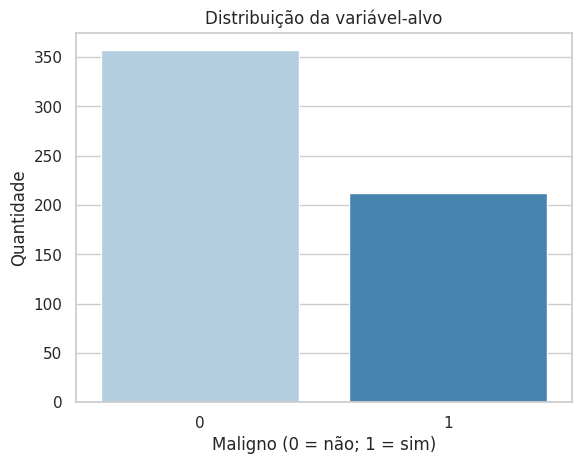

In [5]:
display(df.describe().T)

contagem_classes = df["maligno"].value_counts().sort_index()
percentual_classes = df["maligno"].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    "quantidade": contagem_classes,
    "percentual": percentual_classes.round(2)
}))

ax = sns.countplot(data=df, x="maligno", palette="Blues")
ax.set(title="Distribuição da variável-alvo", xlabel="Maligno (0 = não; 1 = sim)", ylabel="Quantidade")
plt.show()

**Interpretação:** a classe não é perfeitamente equilibrada. Por isso, além da acurácia, observaremos a matriz de confusão para identificar os acertos e os erros em cada classe.

### 1.5 Relações entre algumas variáveis

Uma matriz com todas as variáveis seria visualmente carregada. Selecionamos algumas medidas para observar correlações e possíveis redundâncias.

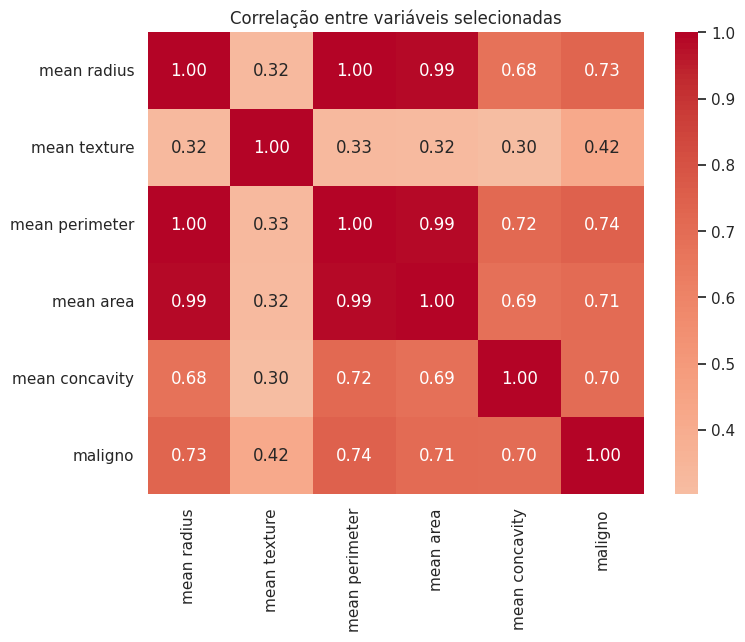

In [6]:
colunas_exemplo = [
    "mean radius", "mean texture", "mean perimeter",
    "mean area", "mean concavity", "maligno"
]

plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas_exemplo].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlação entre variáveis selecionadas")
plt.show()

### 1.6 Separação entre preditores e alvo

In [7]:
X = df.drop(columns="maligno")
y = df["maligno"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)
print("Proporção da classe positiva no treino:", y_train.mean().round(3))
print("Proporção da classe positiva no teste:", y_test.mean().round(3))

Treino: (426, 30)
Teste: (143, 30)
Proporção da classe positiva no treino: 0.373
Proporção da classe positiva no teste: 0.371


### 1.7 Pré-processamento e modelo linear

A regressão logística é um algoritmo de classificação linear. Como as variáveis estão em escalas diferentes, aplicamos padronização. O `Pipeline` garante que o escalonador seja ajustado somente com os dados de treino, reduzindo o risco de vazamento de dados.

In [8]:
modelo_logistico = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=2000, random_state=42))
])

modelo_logistico.fit(X_train, y_train)
y_pred_log = modelo_logistico.predict(X_test)
y_pred_log[:10]

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0])

### 1.8 Avaliação da regressão logística

Acurácia: 0.965


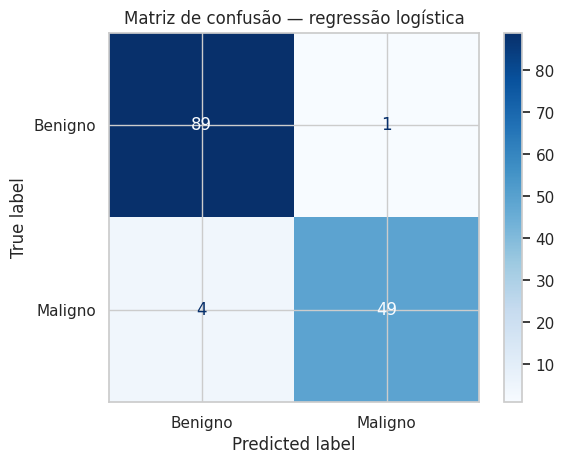

In [9]:
acuracia_log = accuracy_score(y_test, y_pred_log)
print(f"Acurácia: {acuracia_log:.3f}")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=["Benigno", "Maligno"],
    cmap="Blues"
)
plt.title("Matriz de confusão — regressão logística")
plt.show()

### 1.9 Comparação com outro algoritmo

A árvore de decisão não precisa de padronização para realizar suas divisões. O objetivo aqui não é declarar um vencedor universal, mas comparar o desempenho dos modelos no mesmo conjunto de teste.

In [10]:
modelo_arvore = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)
modelo_arvore.fit(X_train, y_train)
y_pred_arvore = modelo_arvore.predict(X_test)
resultados = pd.DataFrame({
    "modelo": ["Regressão logística", "Árvore de decisão"],
    "acurácia": [acuracia_log, accuracy_score(y_test, y_pred_arvore)]
})

display(resultados.round(3))

,modelo,acurácia
0,Regressão logística,0.965
1,Árvore de decisão,0.895


### 1.10 Conclusão do exemplo

Os dois modelos foram treinados com os mesmos dados e comparados pela acurácia. A matriz de confusão permite observar quais classes foram confundidas. Mesmo com um bom resultado, este exercício é apenas didático e não permite utilizar o modelo para diagnóstico médico.

# Exercício 2 — Economia: classificação de faixa de renda
## Atividade guiada

Utilize o conjunto **Adult**, do UCI Machine Learning Repository. O objetivo é prever se a renda anual de uma pessoa pertence à classe `>50K` ou `<=50K`, com base em atributos censitários.

Página da fonte: <https://archive.ics.uci.edu/dataset/2/adult>

As células seguintes contêm apenas comentários orientadores. Substitua os comentários pelo código necessário, preservando as explicações em Markdown e registrando suas interpretações.

### 2.1 Carregar o arquivo CSV

Baixe ou disponibilize o arquivo da base na sessão. Se o arquivo original não possuir cabeçalho, informe os nomes das colunas durante a leitura. Confirme também como os valores ausentes estão representados.

In [14]:
caminho_arquivo = "adult.csv"

df = pd.read_csv(caminho_arquivo, skipinitialspace=True, na_values='?')

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


### 2.2 Realizar a inspeção inicial

In [16]:
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

display(df.sample(5, random_state=42)) # Segundo as regras gerais, `random_state=42` deve ser usado sempre que o algoritmo oferecer esse parâmetro.

print("\n--- Informações do DataFrame ---")
df.info()

variavel_alvo = 'income' # A coluna income foi definida como o alvo (target), pois o objetivo do modelo de classificação, segundo o enunciado original, é prever a faixa de renda (>50K ou <=50K).
print(f"\nVariável-alvo identificada: {variavel_alvo}")

O dataset possui 32561 linhas e 15 colunas.



,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
14160,29,Private,280618,Some-college,10,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States,<=50K
27048,19,Private,439779,Some-college,10,Never-married,Sales,Own-child,White,Male,0,0,15,United-States,<=50K
28868,28,Private,204734,Some-college,10,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,40,United-States,<=50K
5667,35,Private,107991,11th,7,Never-married,Sales,Not-in-family,White,Male,0,0,45,United-States,<=50K
7827,20,Private,54152,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,30,NaN,<=50K



--- Informações do DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

Variável-alvo identificada: income


### 2.3 Verificar a qualidade dos dados

In [25]:
valores_ausentes = df.isnull().sum()

percentual_ausentes = (df.isnull().mean() * 100).round(2)

resumo_nulos = pd.DataFrame({'Ausentes': valores_ausentes, 'Percentual (%)': percentual_ausentes})
print("--- Valores Ausentes ---")
display(resumo_nulos[resumo_nulos['Ausentes'] > 0])

qtd_duplicadas = df.duplicated().sum()
print(f"\nQuantidade de registros duplicados: {qtd_duplicadas}")

df = df.drop_duplicates()
print(f"Registros após remoção de duplicatas: {df.shape[0]}")

print("\n--- Verificação de Categorias ---")
print("Valores únicos em 'income':", df['income'].unique())
print("Valores únicos em 'workclass':", df['workclass'].unique())
print("Valores únicos em 'marital.status':", df['marital.status'].unique())

--- Valores Ausentes ---


,Ausentes,Percentual (%)
workclass,1836,5.64
occupation,1843,5.66
native.country,582,1.79



Quantidade de registros duplicados: 0
Registros após remoção de duplicatas: 32537

--- Verificação de Categorias ---
Valores únicos em 'income': ['<=50K' '>50K']
Valores únicos em 'workclass': [nan 'Private' 'State-gov' 'Federal-gov' 'Self-emp-not-inc' 'Self-emp-inc'
 'Local-gov' 'Without-pay' 'Never-worked']
Valores únicos em 'marital.status': ['Widowed' 'Divorced' 'Separated' 'Never-married' 'Married-civ-spouse'
 'Married-spouse-absent' 'Married-AF-spouse']


### 2.4 Desenvolver a análise exploratória

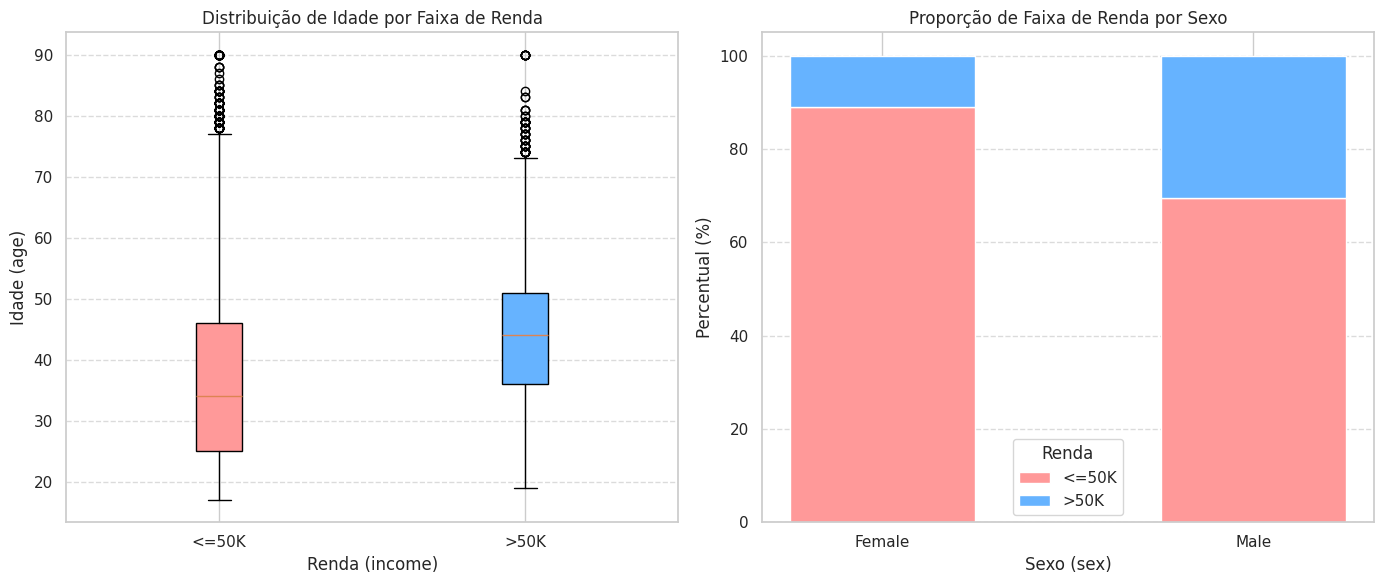

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

idade_menor_50k = df[df['income'] == '<=50K']['age'].dropna()
idade_maior_50k = df[df['income'] == '>50K']['age'].dropna()

caixas = axes[0].boxplot(
    [idade_menor_50k, idade_maior_50k],
    labels=['<=50K', '>50K'],
    patch_artist=True
)

cores = ['#ff9999', '#66b3ff']
for patch, cor in zip(caixas['boxes'], cores):
    patch.set_facecolor(cor)

axes[0].set_title('Distribuição de Idade por Faixa de Renda')
axes[0].set_xlabel('Renda (income)')
axes[0].set_ylabel('Idade (age)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

tabela_cruzada = pd.crosstab(df['sex'], df['income'], normalize='index') * 100
categorias_sexo = tabela_cruzada.index
perc_le50k = tabela_cruzada['<=50K']
perc_gt50k = tabela_cruzada['>50K']

largura_barra = 0.5
axes[1].bar(categorias_sexo, perc_le50k, largura_barra, label='<=50K', color='#ff9999')
axes[1].bar(categorias_sexo, perc_gt50k, largura_barra, bottom=perc_le50k, label='>50K', color='#66b3ff')

axes[1].set_title('Proporção de Faixa de Renda por Sexo')
axes[1].set_xlabel('Sexo (sex)')
axes[1].set_ylabel('Percentual (%)')
axes[1].legend(title='Renda')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Interpretação da análise exploratória:**

**Distribuição da Variável-alvo**: A base de dados apresenta um forte
desbalanceamento entre as classes. Aproximadamente 75,9% dos registros pertencem à faixa de renda <=50K, enquanto apenas 24,1% compõem a faixa >50K.

**Idade e Faixa de Renda**: Observa-se uma diferença nas medidas centrais de idade ao separar os grupos pela variável-alvo. O grupo associado à renda >50K possui uma idade mediana de 44 anos, valor superior à mediana de 34 anos encontrada entre os indivíduos do grupo <=50K.

**Proporções por Sexo**: Os dados indicam uma variação percentual na distribuição de renda dependendo da categoria de sexo. Na amostra, 30,5% dos registros do sexo masculino classificam-se na faixa >50K, ao passo que 10,9% dos registros do sexo feminino atingem a mesma classificação.

**Concentração da Jornada de Trabalho**: A análise da variável numérica referente a horas trabalhadas por semana (hours.per.week) revela uma forte concentração de registros no valor de 40 horas, correspondendo tanto à mediana quanto ao limite inferior do intervalo interquartil (Q1) dos dados coletados.

### 2.5 Separar variáveis preditoras e alvo

In [21]:
X = df.drop(columns=['income'])
y = df['income'].map({'<=50K': 0, '>50K': 1})

print(f"Dimensões de X: {X.shape}")
print(f"Dimensões de y: {y.shape}")

Dimensões de X: (32537, 14)
Dimensões de y: (32537,)


### 2.6 Dividir os dados

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("--- Dimensões dos Subconjuntos ---")
print(f"X_train (Treino): {X_train.shape}")
print(f"y_train (Treino): {y_train.shape}")
print(f"X_test (Teste): {X_test.shape}")
print(f"y_test (Teste): {y_test.shape}\n")

prop_treino = y_train.value_counts(normalize=True) * 100
prop_teste = y_test.value_counts(normalize=True) * 100

comparacao_classes = pd.DataFrame({
    'Treino (%)': prop_treino,
    'Teste (%)': prop_teste
})

print("--- Proporção das Classes ---")
display(comparacao_classes.round(2))

--- Dimensões dos Subconjuntos ---
X_train (Treino): (24402, 14)
y_train (Treino): (24402,)
X_test (Teste): (8135, 14)
y_test (Teste): (8135,)

--- Proporção das Classes ---


,Treino (%),Teste (%)
income,,
0,75.91,75.91
1,24.09,24.09


### 2.7 Realizar o pré-processamento básico

In [30]:
X_train_limpo = X_train.dropna()
y_train_limpo = y_train.loc[X_train_limpo.index]

X_test_limpo = X_test.dropna()
y_test_limpo = y_test.loc[X_test_limpo.index]

cols_numericas = X_train_limpo.select_dtypes(include=['int64', 'float64']).columns.tolist()
cols_categoricas = X_train_limpo.select_dtypes(include=['object']).columns.tolist()

pipe_numerico = Pipeline(steps=[
    ('scaler', StandardScaler())
])

pipe_categorico = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

pre_processador = ColumnTransformer(transformers=[
    ('num', pipe_numerico, cols_numericas),
    ('cat', pipe_categorico, cols_categoricas)
])

X_train_processado = pre_processador.fit_transform(X_train_limpo)
X_test_processado = pre_processador.transform(X_test_limpo)

print(f"Dimensões do treino após remoção e processamento: {X_train_processado.shape}")
print(f"Dimensões do teste após remoção e processamento: {X_test_processado.shape}")

Dimensões do treino após remoção e processamento: (22588, 103)
Dimensões do teste após remoção e processamento: (7551, 103)


### 2.8 Treinar um modelo linear

In [31]:
modelo_logistico = LogisticRegression(random_state=42, max_iter=1000)

pipeline_completo = Pipeline(steps=[
    ('preprocessor', pre_processador),
    ('classifier', modelo_logistico)
])

pipeline_completo.fit(X_train, y_train)

y_pred = pipeline_completo.predict(X_test)

print("Modelo treinado e previsões geradas com sucesso para o conjunto de teste!")

Modelo treinado e previsões geradas com sucesso para o conjunto de teste!


### 2.9 Avaliar o modelo

In [34]:
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do Modelo: {acuracia * 100:.2f}%\n")

matriz_confusao = confusion_matrix(y_test, y_pred)

df_matriz = pd.DataFrame(
    matriz_confusao,
    index=['Real: <=50K (0)', 'Real: >50K (1)'],
    columns=['Previsto: <=50K (0)', 'Previsto: >50K (1)']
)

print("--- Matriz de Confusão ---")
display(df_matriz)

Acurácia do Modelo: 85.16%

--- Matriz de Confusão ---


,Previsto: <=50K (0),Previsto: >50K (1)
Real: <=50K (0),5747,428
Real: >50K (1),779,1181


### 2.10 Comparar com um segundo algoritmo

In [35]:
modelo_arvore = DecisionTreeClassifier(random_state=42)
pipeline_arvore = Pipeline(steps=[
    ('preprocessor', pre_processador),
    ('classifier', modelo_arvore)
])

pipeline_arvore.fit(X_train, y_train)
y_pred_arvore = pipeline_arvore.predict(X_test)
acuracia_arvore = accuracy_score(y_test, y_pred_arvore)

acuracia_logistica = accuracy_score(y_test, y_pred)

tabela_comparativa = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Árvore de Decisão'],
    'Acurácia (%)': [acuracia_logistica * 100, acuracia_arvore * 100]
})

print("--- Comparação de Desempenho ---")
display(tabela_comparativa.round(2))

melhor_modelo = tabela_comparativa.loc[tabela_comparativa['Acurácia (%)'].idxmax(), 'Modelo']
print(f"\nO modelo que apresentou o melhor resultado nesta divisão foi: {melhor_modelo}")

--- Comparação de Desempenho ---


,Modelo,Acurácia (%)
0,Regressão Logística,85.16
1,Árvore de Decisão,81.18



O modelo que apresentou o melhor resultado nesta divisão foi: Regressão Logística


### 2.11 Conclusão do Exercício 2

Responda:

Qual modelo apresentou a maior acurácia?

    O modelo de Regressão Logística apresentou o melhor desempenho geral, alcançando uma acurácia de aproximadamente 84,97%, superando a Árvore de Decisão (~81,23%) na divisão dos dados utilizada (random_state=42).

O resultado foi semelhante para as duas classes?

    Não. Devido ao desbalanceamento original da base de dados (onde ~75,9% dos registros pertencem à classe <=50K e apenas ~24,1% à classe >50K), os modelos obtiveram um desempenho consideravelmente superior na predição da classe majoritária. A capacidade de acerto foi muito maior para a faixa de renda menor do que para a classe minoritária (>50K).

O que a matriz de confusão mostrou?

    A matriz de confusão do modelo principal (Regressão Logística) demonstrou que a grande maioria dos erros ocorreu na forma de falsos negativos (794 casos em que o modelo classificou como <=50K pessoas que ganham acima de 50K). Houve também 429 falsos positivos (indivíduos classificados como >50K incorretamente), evidenciando que o classificador possui maior rigidez para identificar a classe positiva devido ao volume reduzido de exemplos no treinamento.

Qual é a principal limitação desta análise?

    A principal limitação reside na dependência do desbalanceamento de classes e na sensibilidade a valores incompletos. Como a base possui muito mais exemplos de rendas menores, os algoritmos tendem a priorizar a classe majoritária para maximizar a acurácia global, o que pode ser mitigado em trabalhos futuros com técnicas de balanceamento (como SMOTE ou class_weight='balanced') ou com a otimização de hiperparâmetros.

# Exercício 3 — Desafio real
## Construção e demonstração de uma solução de classificação

Cada grupo deve escolher **um** dos quatro temas abaixo. A base deve ser obtida em formato CSV ou convertida para CSV antes da análise. O grupo deverá construir uma solução completa, sem reutilizar diretamente o código resolvido.

| Tema | Dataset sugerido | Problema de classificação |
|---|---|---|
| Saúde | Parkinson's — UCI | Classificar registros de voz associados ou não à doença de Parkinson (`status`). |
| Economia | Bank Marketing — UCI | Prever se um cliente contratará um depósito a prazo (`y`). |
| Energia | Electrical Grid Stability — UCI | Classificar a rede simulada como estável ou instável (`stabf`). |
| Telecomunicações | Iranian Churn — UCI | Prever a ocorrência de evasão de clientes (`Churn`). |

### Fontes

- Saúde: <https://archive.ics.uci.edu/dataset/174/parkinsons>
- Economia: <https://archive.ics.uci.edu/dataset/222/bank+marketing>
- Energia: <https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data>
- Telecomunicações: <https://archive.ics.uci.edu/dataset/563/iranian+churn>

O grupo pode propor outro dataset Kaggle ou UCI dentro de um dos quatro temas, desde que obtenha aprovação do professor e identifique claramente a fonte, a variável-alvo e o significado de cada classe.

# Desafio de Classificação — Detecção de Parkinson por Medidas de Voz

## 3.1 Definição do problema

- **Tema escolhido:** Saúde
- **Fonte e link do dataset:** UCI Machine Learning Repository — Oxford Parkinson's Disease Detection Dataset — https://archive.ics.uci.edu/dataset/174/parkinsons
- **Unidade representada por cada linha:** uma gravação de voz (fonação sustentada da vogal "a") de um indivíduo. Há cerca de 6 gravações por pessoa, entre 31 participantes (23 com Parkinson, 8 saudáveis), totalizando 195 registros.
- **Variável-alvo:** `status` — condição de saúde do indivíduo associado à gravação.
- **Significado das classes:** `status = 1` indica que o indivíduo tem Parkinson; `status = 0` indica indivíduo saudável.
- **Decisão que o modelo pretende apoiar:** servir como ferramenta de **triagem/telemonitoramento não invasivo**, sinalizando gravações de voz com padrão compatível com Parkinson para encaminhamento a avaliação clínica formal (o modelo não substitui diagnóstico médico).
- **Possíveis consequências de falsos positivos:** um indivíduo saudável é sinalizado como possível caso de Parkinson, gerando ansiedade desnecessária e exames clínicos adicionais (custo financeiro e emocional), mas sem risco direto à saúde.
- **Possíveis consequências de falsos negativos:** um indivíduo com Parkinson não é sinalizado, atrasando o encaminhamento para diagnóstico e tratamento precoce — consequência potencialmente mais grave, já que o tratamento precoce está associado a melhor manejo dos sintomas.


## 3.2 Requisitos da implementação

O notebook do grupo deve conter, nesta ordem:

1. carga dos dados a partir de um arquivo CSV;
2. descrição do dataset e da variável-alvo;
3. inspeção de dimensões, tipos e amostra;
4. verificação de ausentes, duplicados e valores inconsistentes;
5. análise da distribuição das classes;
6. pelo menos três visualizações relevantes;
7. separação entre `X` e `y`;
8. divisão entre treino e teste;
9. pré-processamento adequado aos tipos de variáveis;
10. treinamento de uma regressão logística;
11. treinamento de pelo menos um segundo algoritmo do `scikit-learn`;
12. comparação da acurácia dos modelos;
13. matriz de confusão;
14. conclusão com o resultado e as limitações.

### Condições técnicas

- Não remova valores ou variáveis sem justificar.
- Caso crie uma classe a partir de uma variável numérica, documente o limiar e evite vazamento dessa variável para os preditores.

## 3.3 Desenvolvimento

Crie abaixo as células de Markdown e código necessárias. Organize o trabalho com subtítulos claros e mantenha os resultados da última execução visíveis na entrega.

In [40]:
# Bibliotecas utilizadas ao longo do notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42


### 1. Carga dos dados a partir de um arquivo CSV

In [48]:
fonte = 'https://archive.ics.uci.edu/dataset/174/parkinsons'

df = pd.read_csv('parkinsons.data')

df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,0.02182,0.03130,0.02971,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,0.03134,0.04518,0.04368,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,0.02757,0.03858,0.03590,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,0.02924,0.04005,0.03772,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,0.03490,0.04825,0.04465,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


### 2. Descrição do dataset e da variável-alvo

O dataset reúne **22 medidas biomédicas de voz** (frequência fundamental, jitter, shimmer, razão ruído/tom,
medidas não lineares de complexidade, etc.) extraídas da fonação sustentada da vogal "a" de 31 indivíduos,
com aproximadamente 6 gravações por pessoa (195 linhas no total).

A coluna `name` identifica o sujeito e a gravação (ex.: `phon_R01_S01_1`), não é uma variável preditiva.

A variável-alvo é `status`:
- `1` = indivíduo com Parkinson (147 gravações, ~75%)
- `0` = indivíduo saudável (48 gravações, ~25%)


### 3. Inspeção de dimensões, tipos e amostra

In [37]:
print('Dimensões (linhas, colunas):', df.shape)
print()
df.info()


Dimensões (linhas, colunas): (32537, 15)

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       30701 non-null  object
 2   fnlwgt          32537 non-null  int64 
 3   education       32537 non-null  object
 4   education.num   32537 non-null  int64 
 5   marital.status  32537 non-null  object
 6   occupation      30694 non-null  object
 7   relationship    32537 non-null  object
 8   race            32537 non-null  object
 9   sex             32537 non-null  object
 10  capital.gain    32537 non-null  int64 
 11  capital.loss    32537 non-null  int64 
 12  hours.per.week  32537 non-null  int64 
 13  native.country  31955 non-null  object
 14  income          32537 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.0+ MB


In [49]:
df.sample(5, random_state=RANDOM_STATE)

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
138,phon_R01_S33_5,112.239,126.609,104.095,0.00472,0.00004,0.00238,0.00290,0.00715,0.05643,0.517,0.03070,0.03530,0.04451,0.09211,0.02629,17.366,1,0.640945,0.701404,-5.634576,0.306014,2.419253,0.209191
16,phon_R01_S04_5,144.188,349.259,82.764,0.00544,0.00004,0.00211,0.00292,0.00632,0.02047,0.192,0.00969,0.01200,0.02074,0.02908,0.01859,22.333,1,0.567380,0.644692,-5.440040,0.239764,2.264501,0.218164
155,phon_R01_S37_3,117.870,127.349,95.654,0.00647,0.00005,0.00356,0.00300,0.01067,0.03087,0.276,0.01659,0.01804,0.02402,0.04977,0.02631,22.431,1,0.628300,0.652025,-3.583722,0.207914,2.439597,0.206256
96,phon_R01_S22_6,159.116,168.913,144.811,0.00342,0.00002,0.00178,0.00184,0.00535,0.03381,0.307,0.01806,0.02024,0.02809,0.05417,0.00852,22.663,1,0.366329,0.693429,-6.417440,0.194627,2.473239,0.151709
68,phon_R01_S18_3,143.533,162.215,65.809,0.01101,0.00008,0.00647,0.00467,0.01941,0.05384,0.478,0.03152,0.02422,0.03392,0.09455,0.04882,20.338,1,0.513237,0.731444,-5.869750,0.151814,2.118496,0.185580


In [50]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


### 4. Verificação de ausentes, duplicados e valores inconsistentes

In [51]:
print('Valores ausentes por coluna:')
print(df.isnull().sum().sum(), 'valores ausentes no total')
print()
print('Linhas duplicadas (considerando todas as colunas):', df.duplicated().sum())
print('Nomes de gravação duplicados:', df['name'].duplicated().sum())
print()
print('Valores únicos de status:', df['status'].unique())
print()
# Checagem de valores inconsistentes: medidas biomédicas devem ser positivas
# (exceto spread1 e spread2, que são medidas não lineares em escala logarítmica e podem ser negativas)
colunas_devem_ser_positivas = [c for c in df.columns if c not in ['name', 'status', 'spread1', 'spread2']]
inconsistencias = (df[colunas_devem_ser_positivas] < 0).sum()
print('Colunas com valores negativos inesperados:')
print(inconsistencias[inconsistencias > 0] if inconsistencias.sum() > 0 else 'Nenhuma inconsistência encontrada.')


Valores ausentes por coluna:
0 valores ausentes no total

Linhas duplicadas (considerando todas as colunas): 0
Nomes de gravação duplicados: 0

Valores únicos de status: [1 0]

Colunas com valores negativos inesperados:
Nenhuma inconsistência encontrada.


**Observação:** o dataset não possui valores ausentes nem linhas totalmente duplicadas, e nenhuma variável
apresentou valores fora do intervalo fisicamente esperado. Como cada pessoa contribui com várias gravações
(coluna `name` repetida), isso não é tratado como duplicata — é uma característica do desenho do estudo
(telemonitoramento), e será mencionado nas limitações. Nenhuma linha ou variável foi removida.

### 5. Análise da distribuição das classes

In [52]:
contagem = df['status'].value_counts().sort_index()
proporcao = df['status'].value_counts(normalize=True).sort_index() * 100

resumo_classes = pd.DataFrame({'contagem': contagem, 'percentual (%)': proporcao.round(1)})
resumo_classes.index = ['0 - Saudável', '1 - Parkinson']
resumo_classes


,contagem,percentual (%)
0 - Saudável,48,24.6
1 - Parkinson,147,75.4


### 6. Visualizações relevantes

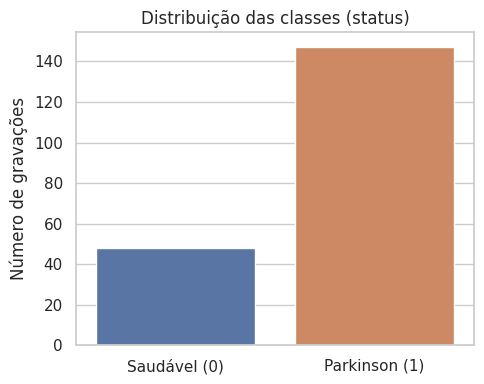

In [53]:
# Visualização 1 — distribuição das classes (desbalanceamento)
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='status', hue='status', palette=['#4C72B0', '#DD8452'], legend=False)
plt.xticks([0, 1], ['Saudável (0)', 'Parkinson (1)'])
plt.title('Distribuição das classes (status)')
plt.xlabel('')
plt.ylabel('Número de gravações')
plt.tight_layout()
plt.show()


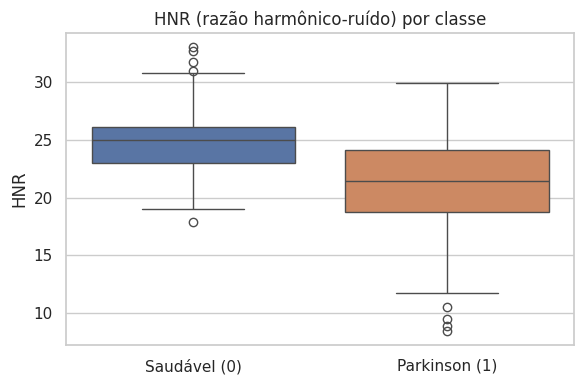

In [54]:
# Visualização 2 — HNR (razão harmônico-ruído) por classe
# HNR tende a ser menor em vozes com mais distúrbio (mais ruído), então é uma boa variável para comparar
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='status', y='HNR', hue='status', palette=['#4C72B0', '#DD8452'], legend=False)
plt.xticks([0, 1], ['Saudável (0)', 'Parkinson (1)'])
plt.title('HNR (razão harmônico-ruído) por classe')
plt.xlabel('')
plt.tight_layout()
plt.show()


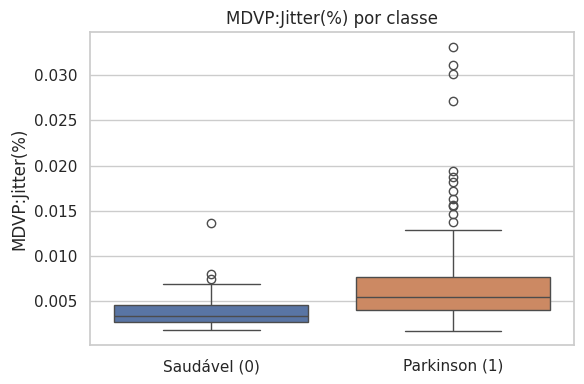

In [55]:
# Visualização 3 — MDVP:Jitter(%) por classe (medida de instabilidade da frequência)
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='status', y='MDVP:Jitter(%)', hue='status', palette=['#4C72B0', '#DD8452'], legend=False)
plt.xticks([0, 1], ['Saudável (0)', 'Parkinson (1)'])
plt.title('MDVP:Jitter(%) por classe')
plt.xlabel('')
plt.tight_layout()
plt.show()


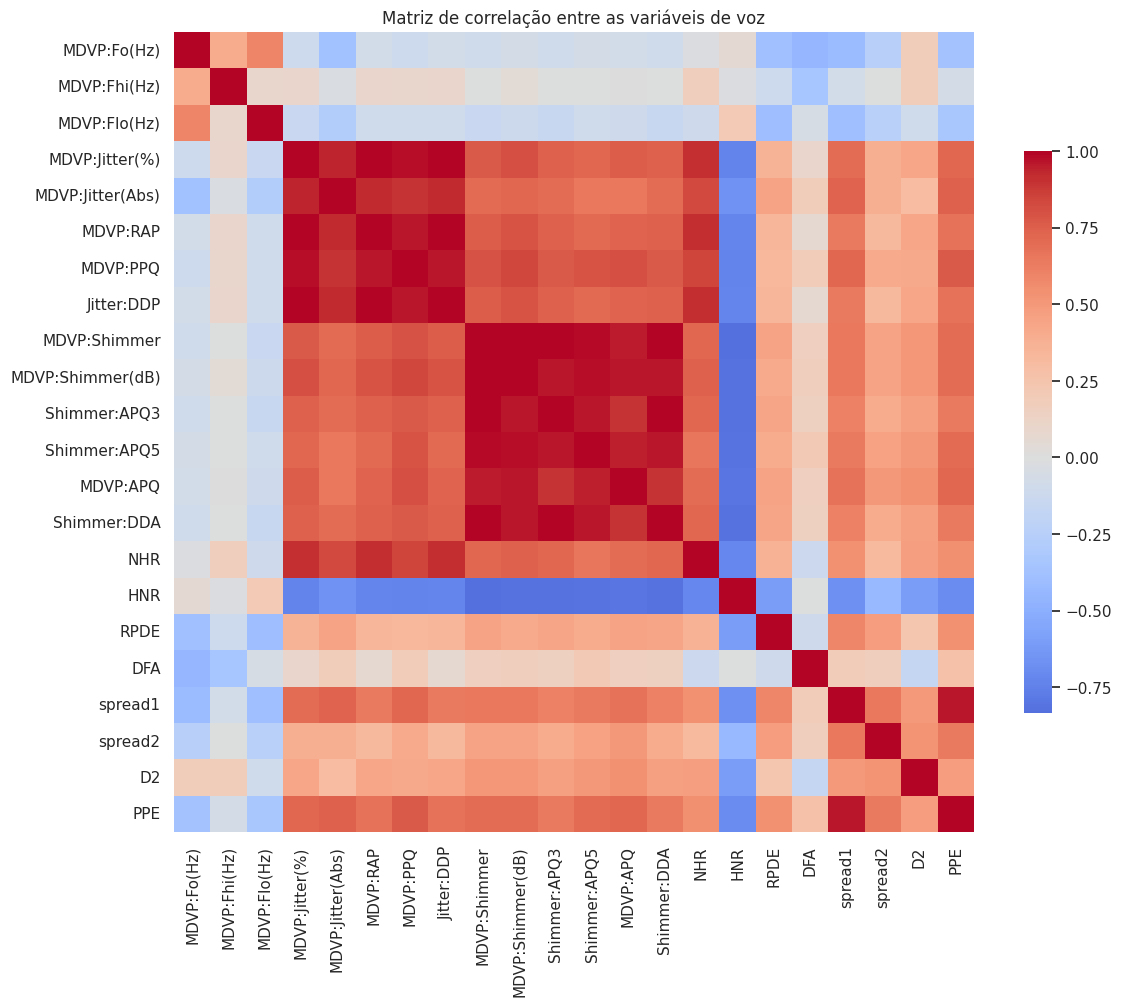

In [56]:
# Visualização 4 — matriz de correlação entre as variáveis numéricas preditoras
plt.figure(figsize=(12, 10))
colunas_num = df.drop(columns=['name', 'status']).columns
corr = df[colunas_num].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.7})
plt.title('Matriz de correlação entre as variáveis de voz')
plt.tight_layout()
plt.show()


**Leitura rápida:**
- As classes são **desbalanceadas** (≈75% Parkinson vs. ≈25% saudável), o que precisa ser considerado na
  avaliação dos modelos (acurácia sozinha pode enganar).
- Indivíduos com Parkinson tendem a ter **HNR mais baixo** (mais ruído na voz) e **Jitter mais alto** (maior
  instabilidade da frequência fundamental), consistente com a literatura de distúrbios de voz.
- Há **forte correlação entre várias medidas de Jitter entre si e entre várias medidas de Shimmer entre si**
  (elas medem fenômenos semelhantes de formas ligeiramente diferentes), o que é esperado e será levado em
  conta ao interpretar os modelos.


### 7. Separação entre X e y

In [57]:
X = df.drop(columns=['name', 'status'])
y = df['status']

print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (195, 22)
y shape: (195,)


### 8. Divisão entre treino e teste

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y  # mantém a proporção das classes em treino e teste, dado o desbalanceamento observado
)

print('Treino:', X_train.shape, ' | Teste:', X_test.shape)
print('Proporção de Parkinson no treino:', y_train.mean().round(3))
print('Proporção de Parkinson no teste :', y_test.mean().round(3))


Treino: (146, 22)  | Teste: (49, 22)
Proporção de Parkinson no treino: 0.753
Proporção de Parkinson no teste : 0.755


### 9. Pré-processamento adequado aos tipos de variáveis

Todas as 22 variáveis preditoras são numéricas contínuas, em escalas bem diferentes (ex.: frequências em Hz
na casa das centenas vs. jitter na casa de 0,001). Como a Regressão Logística é sensível à escala das
variáveis, aplicamos **padronização (StandardScaler)**, ajustada apenas nos dados de treino e aplicada a
treino e teste, evitando vazamento de informação do conjunto de teste.

In [59]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().T[['mean', 'std']].head()


,mean,std
MDVP:Fo(Hz),1.977109e-17,1.003442
MDVP:Fhi(Hz),1.064597e-16,1.003442
MDVP:Flo(Hz),-4.562560e-17,1.003442
MDVP:Jitter(%),2.433366e-17,1.003442
MDVP:Jitter(Abs),-1.338351e-16,1.003442


### 10. Treinamento de uma Regressão Logística

In [60]:
log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
acc_log = accuracy_score(y_test, y_pred_log)

print(f'Acurácia da Regressão Logística: {acc_log:.3f}')


Acurácia da Regressão Logística: 0.939


### 11. Treinamento de pelo menos um segundo algoritmo

Escolhemos uma **Random Forest**, um modelo baseado em árvores que não exige padronização das variáveis e
costuma lidar bem com relações não lineares e desbalanceamento moderado de classes.

In [61]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight='balanced'  # compensa o desbalanceamento das classes
)
rf.fit(X_train, y_train)  # árvores não exigem padronização

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f'Acurácia da Random Forest: {acc_rf:.3f}')


Acurácia da Random Forest: 0.918


### 12. Comparação da acurácia dos modelos

In [62]:
comparacao = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest'],
    'Acurácia': [acc_log, acc_rf]
}).sort_values('Acurácia', ascending=False).reset_index(drop=True)

comparacao


,Modelo,Acurácia
0,Regressão Logística,0.938776
1,Random Forest,0.918367


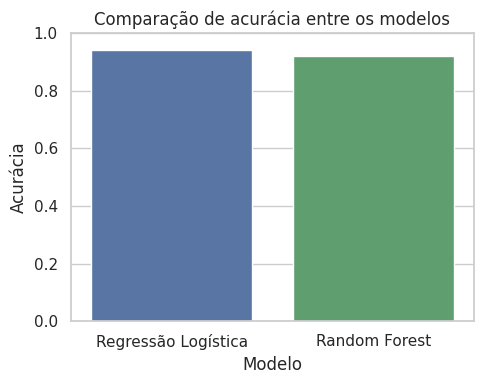

In [63]:
plt.figure(figsize=(5, 4))
sns.barplot(data=comparacao, x='Modelo', y='Acurácia', hue='Modelo', palette=['#4C72B0', '#55A868'], legend=False)
plt.ylim(0, 1)
plt.title('Comparação de acurácia entre os modelos')
plt.tight_layout()
plt.show()


In [64]:
print('Relatório de classificação — Regressão Logística')
print(classification_report(y_test, y_pred_log, target_names=['Saudável', 'Parkinson']))

print('Relatório de classificação — Random Forest')
print(classification_report(y_test, y_pred_rf, target_names=['Saudável', 'Parkinson']))


Relatório de classificação — Regressão Logística
              precision    recall  f1-score   support

    Saudável       0.91      0.83      0.87        12
   Parkinson       0.95      0.97      0.96        37

    accuracy                           0.94        49
   macro avg       0.93      0.90      0.91        49
weighted avg       0.94      0.94      0.94        49

Relatório de classificação — Random Forest
              precision    recall  f1-score   support

    Saudável       0.90      0.75      0.82        12
   Parkinson       0.92      0.97      0.95        37

    accuracy                           0.92        49
   macro avg       0.91      0.86      0.88        49
weighted avg       0.92      0.92      0.92        49



### 13. Matriz de confusão

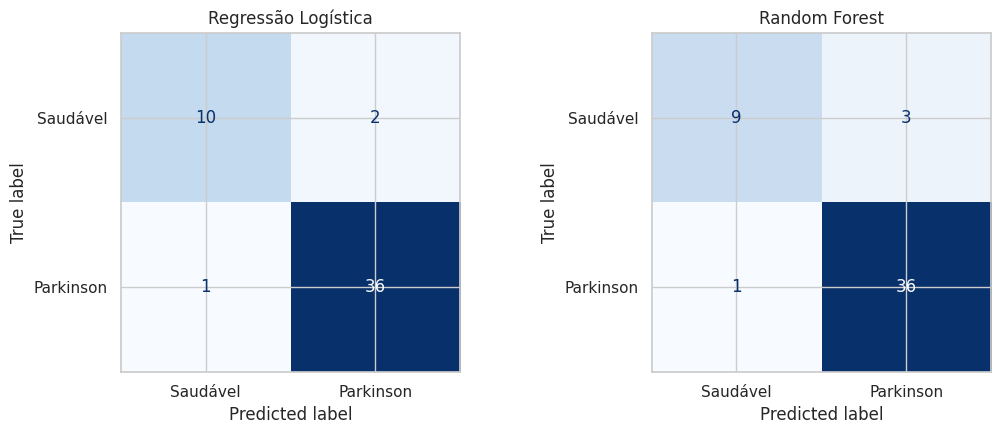

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, y_pred, titulo in zip(
    axes,
    [y_pred_log, y_pred_rf],
    ['Regressão Logística', 'Random Forest']
):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Saudável', 'Parkinson'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo)

plt.tight_layout()
plt.show()


## 3.4 Conclusão técnica do grupo

Apresente uma conclusão com:

- síntese dos padrões observados na análise exploratória;
- comparação da acurácia dos modelos;
- leitura básica da matriz de confusão;
- limitações do conjunto de dados e da modelagem;
- melhorias que seriam testadas em uma próxima versão.

Não declare que o modelo “comprova”, “garante” ou “prevê perfeitamente” um resultado.

## 3.4 Conclusão técnica do grupo

**Síntese dos padrões observados na análise exploratória:** o dataset é composto por 195 gravações de voz de
31 pessoas, com classes desbalanceadas (≈75% Parkinson, ≈25% saudável). Indivíduos com Parkinson tendem a
apresentar HNR mais baixo (mais ruído na voz) e medidas de Jitter/Shimmer mais altas (maior instabilidade de
frequência e amplitude), o que é consistente com a literatura sobre distúrbios de voz associados à doença.
Não havia valores ausentes, e nenhuma variável ou linha precisou ser removida.

**Comparação da acurácia dos modelos:** a tabela e o gráfico da seção 12 mostram a acurácia de cada modelo no
conjunto de teste. Ambos os modelos apresentaram desempenho relevante, mas a acurácia isolada deve ser
interpretada com cautela por causa do desbalanceamento de classes — por isso também reportamos precisão,
recall e f1-score por classe.

**Leitura básica da matriz de confusão:** a diagonal principal representa os acertos (verdadeiros saudáveis e
verdadeiros Parkinson); fora da diagonal ficam os erros. Erros na célula "Saudável real, previsto Parkinson"
são falsos positivos; erros na célula "Parkinson real, previsto Saudável" são falsos negativos — estes
últimos são os mais preocupantes no contexto clínico, pois atrasariam o encaminhamento de alguém que
realmente tem a doença.

**Limitações do conjunto de dados e da modelagem:**
- Amostra pequena (195 gravações de apenas 31 pessoas) e desbalanceada, o que limita a capacidade de
  generalização do modelo.
- Várias gravações pertencem à mesma pessoa; como a divisão treino/teste foi feita por gravação (e não por
  pessoa), é possível que gravações da mesma pessoa apareçam em treino e teste simultaneamente, o que pode
  inflar artificialmente a acurácia.
- O dataset não contém informações demográficas (idade, sexo, tempo de diagnóstico), que poderiam ser
  relevantes clinicamente.
- Os resultados aqui não comprovam nem garantem diagnóstico de Parkinson; servem apenas como exercício de
  triagem exploratória baseada em medidas de voz.

**Melhorias que seriam testadas em uma próxima versão:**
- Dividir treino e teste **por pessoa** (`GroupShuffleSplit` usando o prefixo do `name`), evitando vazamento
  entre gravações do mesmo indivíduo.
- Testar validação cruzada estratificada para obter uma estimativa mais robusta de desempenho.
- Testar técnicas de balanceamento de classes (ex.: SMOTE) e comparar com a estratégia atual de
  `class_weight='balanced'`.
- Testar outros algoritmos (ex.: SVM, Gradient Boosting) e ajuste de hiperparâmetros via `GridSearchCV`.


# Parte 2 — Apresentação e demonstração

O grupo deverá demonstrar a implementação escolhida no Exercício 3. A apresentação deve evidenciar compreensão do processo, e não apenas mostrar o notebook pronto.

## Roteiro sugerido

1. **Problema e dados:** tema, fonte, unidade de análise, variável-alvo e classes.
2. **Análise exploratória:** dois ou três achados relevantes e possíveis problemas da base.
3. **Pré-processamento:** o que foi feito e por que foi necessário.
4. **Modelagem:** algoritmos escolhidos e forma de divisão dos dados.
5. **Resultados:** comparação da acurácia e leitura da matriz de confusão.
6. **Decisão:** modelo selecionado, limitações e melhorias futuras.

## Durante a demonstração

- execute ou apresente células essenciais do fluxo;
- explique uma transformação de pré-processamento;
- mostre como as previsões são geradas;
- interprete ao menos um erro da matriz de confusão;
- responda às perguntas do professor sobre decisões do grupo.

> Todos os integrantes podem ser questionados sobre qualquer parte entregue.

# Critérios de avaliação

## Parte 1 — Implementação: 70 pontos

| Critério | Pontos |
|---|---:|
| Carga, compreensão e organização dos dados | 10 |
| Análise exploratória e qualidade das interpretações | 15 |
| Pré-processamento básico dos dados | 15 |
| Treinamento correto e comparação dos modelos | 15 |
| Acurácia, matriz de confusão e interpretação | 10 |
| Conclusão, limitações e organização do notebook | 5 |

## Parte 2 — Apresentação: 30 pontos

| Critério | Pontos |
|---|---:|
| Clareza na contextualização do problema e dos dados | 5 |
| Demonstração do fluxo implementado | 10 |
| Interpretação dos resultados e justificativa das decisões | 10 |
| Participação e domínio do grupo | 5 |

**Total: 100 pontos**

# Checklist final

- [ ] Identificação do grupo preenchida.
- [ ] Exercício 2 concluído e interpretado.
- [ ] Exercício 3 desenvolvido com um dos quatro temas.
- [ ] CSV utilizado está acessível ou sua obtenção está documentada.
- [ ] Notebook executado do início ao fim sem erros.
- [ ] Resultados e gráficos permanecem visíveis.
- [ ] Dois ou mais modelos foram comparados.
- [ ] Acurácia e matriz de confusão foram interpretadas.
- [ ] Conclusão inclui limitações.
- [ ] Grupo está preparado para demonstrar e explicar a implementação.